# Transformada de Fourier de Tiempo Corto

El principal método para realizar análisis de tiempo y frecuencia consiste en realizar transformadas de Fourier en segmentos cortos de la señal $x(t)$. Esto se denomina transformada de Fourier de tiempo corto (STFT en ingles). La STFT se define en base a multiplicar la señal $x(t)$ por una ventana $w(t)$, que es una función que tiene un soporte limitado en el tiempo. La STFT se define como:



$$
\mathbf {STFT} \{x(t)\}(\tau ,\omega )\equiv X(\tau ,\omega )=\int _{-\infty }^{\infty }x(t)w(t-\tau )e^{-i\omega t}\,dt
$$

$$
\mathbf {STFT} \{x[n]\}(m,\omega )\equiv X(m,\omega )=\sum _{n=0}^{N-1}x[n]w[n-m]e^{-i\omega n}
$$

## Ventanas

Existen muchos tipos de ventanas que se pueden usar para la STFT. Algunas son: hann, hamming, rectangular, blackman, etc.

Observemos estos tipos de ventanas y sus transformadas de Fourier.

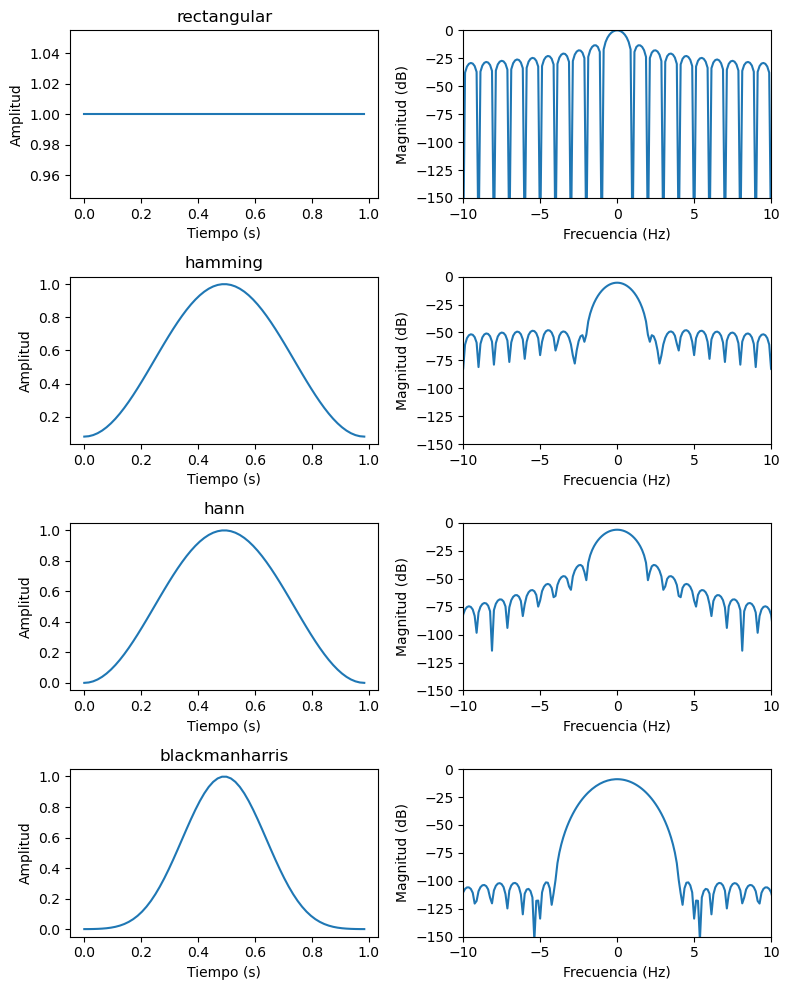

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal.windows import hann, hamming, blackmanharris, boxcar

ifft = np.fft.ifft
fft = np.fft.fft
rfft = np.fft.rfft
irfft = np.fft.irfft
fftshift = np.fft.fftshift
fftfreq = np.fft.fftfreq


def plotspectrum(x, sr=44100.0, xscale='linear', units='db', fmt = '-', ax=None):
    if ax is None:
        ax = plt.gca()
    N = len(x)
    F = 2*(np.abs(rfft(x))/N)**2
    if units=='db':
        F = 10*np.log10(F)
        ylabel = 'Potencia dB'
    else:
        ylabel = 'Potencia'
    df = sr/N
    f = np.arange(F.size)*df
    ax.plot(f,F,fmt)
    ax.set_xscale(xscale)
    ax.set_xlabel('Frecuencia (hz)')
    ax.set_ylabel(ylabel)
    return F


# subplot 3 filas 2 columnas, izquierda ventanas, derecha rfft de las ventanas

N = 64
sr = N
t = np.arange(N)/sr
wins = [boxcar, hamming, hann, blackmanharris]

fig, axs = plt.subplots(len(wins), 2, figsize=(8, 10))

pad = 8
for i, win in enumerate(wins):
    axs[i,0].plot(t,win(N))
    axs[i,0].set_title(f'{win.__name__}'.replace('boxcar','rectangular'))
    axs[i,0].set_xlabel('Tiempo (s)')
    axs[i,0].set_ylabel('Amplitud')
    X = fftshift(np.abs(fft(win(N),N*pad)))/N
    Xdb = 20*np.log10(X+1e-10)
    freqs = fftshift(fftfreq(N*pad,1/sr))
    axs[i,1].plot(freqs,Xdb)
    axs[i,1].set_xlim(-10,10)
    axs[i,1].set_ylim(-150,0)
    axs[i,1].set_xlabel('Frecuencia (Hz)')
    axs[i,1].set_ylabel('Magnitud (dB)')

plt.tight_layout()
plt.show()


## Efecto de la ventana sobre la DFT


Podemos utilizar el teorema de la convolución para entender el efecto de la ventana. La ventana es una función que se multiplica por la señal. Por lo tanto en el dominio de la frecuencia, aplicar la ventana se convierte en una convolución entre la transformada de la señal y la transformada de la ventana. De esta forma utilizar una ventana en la señal uniformisa la DFT.



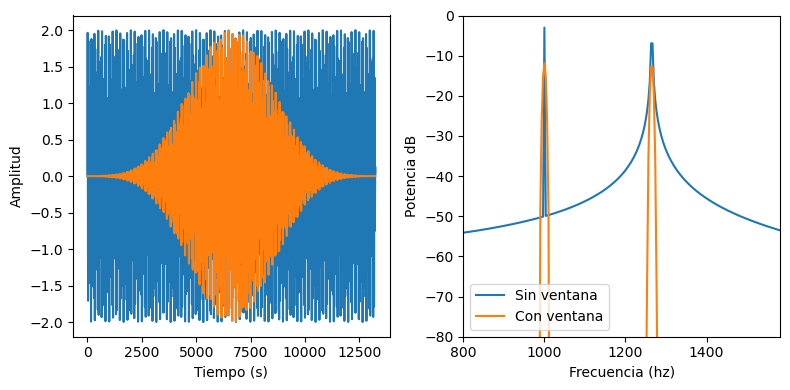

In [3]:
f1 = 1000
f2 = 1265
sr = 44100
N = int(sr*0.3)
t = np.arange(N)/sr
x = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t)
win = blackmanharris(t.size)
y = x*win

fig, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].plot(x)
axs[0].plot(y)

axs[0].set_xlabel('Tiempo (s)')
axs[0].set_ylabel('Amplitud')

plotspectrum(x,ax=axs[1])
plotspectrum(y,ax=axs[1])

axs[1].set_xlim(f1*0.8,f2/0.8)
axs[1].set_ylim(-80, 0)
axs[1].legend(['Sin ventana','Con ventana']);

plt.tight_layout()
plt.show()
